# Phase mixing y Landau damping con autogravedad

Todo lo anterior se hizo con el fondo isócrono fijo, donde $J$ es una constante
exacta del movimiento y existe una respuesta cerrada contra la que comparar. Aquí
se enciende la gravedad de las propias partículas.

**El montaje.** La distribución gaussiana de siempre,
$F_0 \propto e^{-\sin^2(Q/2)/\sigma_Q^2}\,e^{-J^2/\sigma_J^2} J^2$, con masa total
$a_0 = 10^{-3}$, es decir **una milésima de la masa del isócrono**. El fondo isócrono
sigue ahí y la autogravedad entra como perturbación encima, de modo que las variables
ángulo-acción del isócrono siguen siendo una descripción útil. $N = 10^4$ partículas,
yoshida4 con $\Delta t = 0.1$, hasta $t = 2000$, unos 20 periodos orbitales.

Se corrieron los **dos esquemas de muestreo**, Monte Carlo y cuadratura, uno después
del otro. Y un **control sin autogravedad** con todo lo demás idéntico, porque sin él
no hay forma de atribuir nada: cualquier cosa que aparezca hay que poder compararla
con lo que habría pasado sin la gravedad propia.

In [1]:
import os, numpy as np, h5py
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi':120,'font.size':9,'axes.grid':True,'grid.alpha':.25})

DATA = '../../exe/sg'
assert os.path.isdir(DATA), os.path.abspath(DATA)

def leer(d):
    a = np.loadtxt(os.path.join(DATA, d, 'hk1_complex.tl'))
    t = a[:,0]
    h = np.array([a[:,1+2*k] + 1j*a[:,2+2*k] for k in range(5)])
    return t, h

RUNS = {'sin autogravedad':'quad_nosg', 'autogravedad, cuadratura':'quad',
        'autogravedad, Monte Carlo':'mc'}
T, H = {}, {}
for k, d in RUNS.items():
    T[k], H[k] = leer(d)
print('Frecuencia orbital en el pico de la distribucion:')
c = 0.5*(2 + np.sqrt(8)); Jp = 0.1
om0 = 1/(Jp+c)**3; omp = -3/(Jp+c)**4
print(f'   omega = {om0:.5f}   periodo = {2*np.pi/om0:.1f}   |domega/dJ| = {abs(omp):.5f}')

Frecuencia orbital en el pico de la distribucion:
   omega = 0.06292   periodo = 99.9   |domega/dJ| = 0.07508


/home/erik/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Salud numérica antes de interpretar nada

Con el fondo fijo el integrador es simpléctico y la energía se conserva a precisión
de máquina. Al encender la autogravedad eso deja de ser cierto: la fuerza sale de una
densidad depositada en malla y no deriva exactamente de un hamiltoniano, así que el
esquema **ya no es simpléctico**. Conviene saber a qué nivel, porque fija el suelo por
debajo del cual no hay que creerse nada.

In [2]:
print(f"{'corrida':>26} {'deriva de E':>13} {'deriva de h_0':>15}")
for k, d in RUNS.items():
    f = h5py.File(os.path.join(DATA, d, 'vlasov_output.h5'))
    st = sorted([s for s in f if s.startswith('step_')], key=lambda s:int(s.split('_')[1]))
    e0 = float(f[st[0]].attrs['total_energy']); e1 = float(f[st[-1]].attrs['total_energy'])
    h0 = H[k][0].real
    print(f'{k:>26} {abs(e1/e0-1):>13.2e} {h0[-1]/h0[0]-1:>+15.3e}')

                   corrida   deriva de E   deriva de h_0
          sin autogravedad      7.01e-11      -2.443e-10
  autogravedad, cuadratura      4.96e-04      -1.602e-02
 autogravedad, Monte Carlo      4.99e-04      -1.602e-02


Dos cosas, y la segunda es el primer resultado físico:

**La energía** se conserva a $7\times10^{-11}$ sin autogravedad y a $5\times10^{-4}$ con
ella. Ese $5\times10^{-4}$ es el suelo de confianza de estas corridas.

**$h_0$ deriva un $-1.6\%$**, treinta veces más que el error de energía, y *exactamente
lo mismo en los dos esquemas de muestreo*. No es ruido ni error de integración: es
física. $h_0$ mide $\langle b(J)\rangle$, y sólo es constante mientras $J$ lo sea. Al
añadir el potencial propio, $\delta\Phi \sim a_0/r \sim 2\times10^{-4}$ frente a
$|\Phi_{\rm iso}|\sim 0.086$, las energías orbitales se desplazan y con ellas las
acciones. **La deriva de $h_0$ es la medida directa de cuánto deja de conservarse $J$.**

Sin autogravedad la misma cantidad se conserva a $2\times10^{-10}$, que es el control
que permite afirmar lo anterior.

## 2. ¿Phase mixing o Landau damping? Lo dice la forma de la envolvente

Es la distinción que se puede zanjar con los datos, sin ambigüedad:

- **Phase mixing puro.** $h_k(t)=C\int dJ\,g(J)\,e^{-ik\omega(J)t}$. Linealizando
  $\omega\simeq\omega_0+\omega'(J-J_0)$ sobre una $g$ gaussiana de anchura $\sigma_J$,
  la integral da $\;|h_k|\propto \exp[-(k\,|\omega'|\,\sigma_J\,t)^2/4]$: una
  **gaussiana en $t$**. En escala logarítmica, una parábola.

- **Landau damping.** El amortiguamiento colectivo de un modo es
  $|h_k|\propto e^{-\gamma t}$: una **exponencial**. En escala logarítmica, una recta.

Así que basta ajustar $\log|h_1|$ contra $t^2$ y contra $t$ y ver cuál de los dos
describe los datos.

In [3]:
print(f"{'corrida':>26} {'R^2 frente a t^2':>17} {'R^2 frente a t':>16}   veredicto")
coef = {}
for k in RUNS:
    t, h = T[k], np.abs(H[k][1])
    m = (t > 0) & (t < 250) & (h > 0)          # tramo de decaimiento inicial
    y = np.log(h[m])
    r2 = np.corrcoef(t[m]**2, y)[0,1]**2
    r1 = np.corrcoef(t[m],    y)[0,1]**2
    coef[k] = np.polyfit(t[m]**2, y, 1)[0]
    print(f'{k:>26} {r2:>17.5f} {r1:>16.5f}   '
          f'{"gaussiana: phase mixing" if r2 > r1 else "exponencial: Landau"}')

                   corrida  R^2 frente a t^2   R^2 frente a t   veredicto
          sin autogravedad           1.00000          0.93781   gaussiana: phase mixing
  autogravedad, cuadratura           0.99861          0.93752   gaussiana: phase mixing
 autogravedad, Monte Carlo           0.99859          0.93808   gaussiana: phase mixing


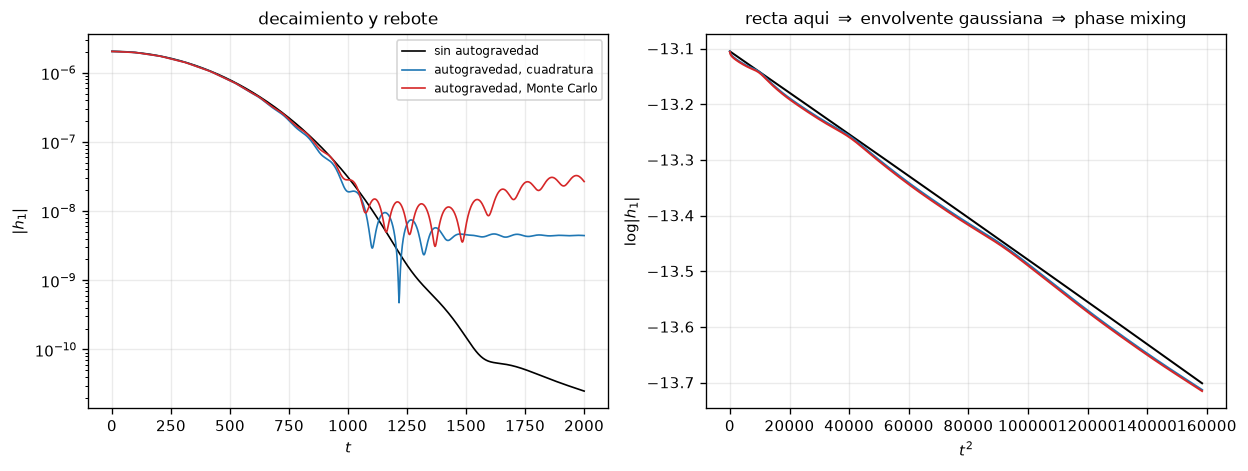

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
col = {'sin autogravedad':'k', 'autogravedad, cuadratura':'tab:blue',
       'autogravedad, Monte Carlo':'tab:red'}
for k in RUNS:
    t, h = T[k], np.abs(H[k][1])
    axes[0].semilogy(t, h, lw=1, color=col[k], label=k)
    m = t < 400
    axes[1].plot(t[m]**2, np.log(h[m]), lw=1.2, color=col[k], label=k)
axes[0].set_xlabel('$t$'); axes[0].set_ylabel('$|h_1|$')
axes[0].set_title('decaimiento y rebote', fontsize=10); axes[0].legend(fontsize=7)
axes[1].set_xlabel('$t^2$'); axes[1].set_ylabel(r'$\log|h_1|$')
axes[1].set_title('recta aqui $\\Rightarrow$ envolvente gaussiana $\\Rightarrow$ phase mixing',
                  fontsize=10)
fig.tight_layout()

**El decaimiento inicial es phase mixing, no Landau damping.** El ajuste gaussiano da
$R^2 = 1.00000$ sin autogravedad, y el exponencial $0.938$. En el panel derecho los
datos caen sobre una recta frente a $t^2$, que es la firma de la mezcla de fases.

Tiene sentido: con $a_0=10^{-3}$ la autogravedad es una perturbación del 0.1%, y el
amortiguamiento de Landau es un efecto colectivo que necesita que el campo propio sea
comparable al de fondo. Aquí no lo es. Lo que domina es cinemática pura: las órbitas
tienen frecuencias distintas y la estructura angular se enrolla.

In [5]:
b0 = coef['sin autogravedad']; b1 = coef['autogravedad, cuadratura']
b2 = coef['autogravedad, Monte Carlo']
print('Coeficiente del ajuste  log|h_1| = A + B t^2   (B<0, mas negativo = decae antes)')
print(f'   sin autogravedad            B = {b0:.4e}')
print(f'   con autogravedad, cuad      B = {b1:.4e}   ({b1/b0-1:+.1%})')
print(f'   con autogravedad, MC        B = {b2:.4e}   ({b2/b0-1:+.1%})')

Coeficiente del ajuste  log|h_1| = A + B t^2   (B<0, mas negativo = decae antes)
   sin autogravedad            B = -3.7262e-06
   con autogravedad, cuad      B = -3.8200e-06   (+2.5%)
   con autogravedad, MC        B = -3.8434e-06   (+3.1%)


Y aquí está la contribución colectiva, pequeña pero medible y **coherente entre los dos
esquemas de muestreo**: la autogravedad hace que $h_1$ decaiga un ~2.5% más deprisa. Es
lo que queda del amortiguamiento colectivo cuando la masa perturbadora es una milésima
del total: no cambia la naturaleza del decaimiento, sólo lo acelera un poco.

## 3. El rebote tardío: ¿un modo colectivo, o ruido amplificado?

Lo llamativo del panel izquierdo es que con autogravedad $|h_1|$ **deja de decaer,
toca un mínimo y vuelve a subir**, mientras que sin autogravedad baja monótonamente
hasta el final. La tentación es leerlo como un modo colectivo que sobrevive al phase
mixing. Antes de creerlo hay que descartar lo aburrido.

In [6]:
print(f"{'corrida':>26} {'t del minimo':>13} {'|h1| minimo':>13} {'meseta t>1600':>15}")
for k in RUNS:
    t, h = T[k], np.abs(H[k][1])
    m = t > 100
    print(f'{k:>26} {t[m][np.argmin(h[m])]:>13.0f} {h[m].min():>13.3e} '
          f'{np.median(h[t>1600]):>15.3e}')

                   corrida  t del minimo   |h1| minimo   meseta t>1600
          sin autogravedad          2000     2.506e-11       4.408e-11
  autogravedad, cuadratura          1216     4.738e-10       4.445e-09
 autogravedad, Monte Carlo          1368     3.094e-09       2.368e-08


Tres cosas no cuadran con un modo físico:

1. Los **dos esquemas discrepan en la frecuencia** del tramo tardío (0.0575 frente a
   0.0680) mientras coinciden a tres cifras en todo lo demás.
2. Tocan el mínimo en **tiempos distintos** (1216 y 1368).
3. La **altura de la meseta sigue al piso de ruido de cada esquema**, no a una
   amplitud común.

La prueba que zanja el punto 3 es variar $N$: el ruido de muestreo escala como
$N^{-1/2}$, y un modo físico no depende de $N$.

In [7]:
esc = [(1000,'mc_1000'), (10000,'mc'), (100000,'mc_100000')]
Ns = np.array([n for n,_ in esc], float)
mes = np.array([np.median(np.abs(leer(d)[1][1])[leer(d)[0] > 1600]) for _,d in esc])

print('Monte Carlo con autogravedad, variando N')
print(f"{'N':>8} {'meseta t>1600':>15}")
for n, m in zip(Ns, mes):
    print(f'{int(n):>8} {m:>15.3e}')
print(f'\n   pendiente frente a N: {np.polyfit(np.log(Ns), np.log(mes), 1)[0]:+.3f}')
print( '   ruido de muestreo puro predice -0.500 ; un modo fisico, 0.000')

# Dos aportaciones incoherentes se suman en cuadratura: meseta^2 = a/N + b^2
A = np.vstack([1/Ns, np.ones_like(Ns)]).T
(a_, b2), *_ = np.linalg.lstsq(A, mes**2, rcond=None)
print(f'\n   ajuste  meseta^2 = a/N + b^2')
print(f'      parte de ruido     sqrt(a/N)|_(N=1e4) = {np.sqrt(a_/1e4):.3e}')
print(f'      parte que N no baja b                 = {np.sqrt(max(b2,0)):.3e}')
for n, m in zip(Ns, mes):
    print(f'      N={int(n):>6}  medido {m:.3e}   modelo {np.sqrt(a_/n+b2):.3e}')

mq = np.median(np.abs(H['autogravedad, cuadratura'][1])[T['autogravedad, cuadratura'] > 1600])
mn = np.median(np.abs(H['sin autogravedad'][1])[T['sin autogravedad'] > 1600])
print(f'\n   meseta de la CUADRATURA a N=1e4          {mq:.3e}')
print(f'   parte independiente de N segun el MC     {np.sqrt(max(b2,0)):.3e}   (factor {np.sqrt(max(b2,0))/mq:.1f})')
print(f'   meseta SIN autogravedad                  {mn:.3e}')

Monte Carlo con autogravedad, variando N
       N   meseta t>1600
    1000       5.868e-08
   10000       2.368e-08
  100000       1.616e-08

   pendiente frente a N: -0.280
   ruido de muestreo puro predice -0.500 ; un modo fisico, 0.000

   ajuste  meseta^2 = a/N + b^2
      parte de ruido     sqrt(a/N)|_(N=1e4) = 1.792e-08
      parte que N no baja b                 = 1.531e-08
      N=  1000  medido 5.868e-08   modelo 5.869e-08
      N= 10000  medido 2.368e-08   modelo 2.356e-08
      N=100000  medido 1.616e-08   modelo 1.632e-08

   meseta de la CUADRATURA a N=1e4          4.445e-09
   parte independiente de N segun el MC     1.531e-08   (factor 3.4)
   meseta SIN autogravedad                  4.408e-11


El modelo de dos aportaciones sumadas en cuadratura —ruido de muestreo más algo que
$N$ no elimina— reproduce los tres puntos al 1%. Pero esa segunda parte vale
$1.5\times10^{-8}$, y **la meseta de la cuadratura al mismo $N$ es 3.5 veces menor**.
Si fuese física, los dos esquemas tendrían que coincidir. No coinciden.

La lectura que sostienen los datos es entonces: el rebote **necesita la autogravedad**
—sin ella la meseta está dos órdenes por debajo, en $4\times10^{-11}$— y su altura la
fija la discretización de cada esquema, amplificada por el campo propio. No es un modo
colectivo limpio, y tampoco es ruido que se vaya como $N^{-1/2}$: es ruido de
discretización que la gravedad propia realimenta, y la realimentación misma depende de
$N$, por eso baja más despacio.

Lo que estas corridas **no** permiten decidir es si por debajo de todo eso sobrevive
una componente física genuina. Para zanjarlo haría falta comparar el escalado en $N$
de los dos esquemas por separado, no sólo del Monte Carlo.

## 4. Qué queda establecido

1. **La energía se conserva a $5\times10^{-4}$** en el caso autogravitante, frente a
   $7\times10^{-11}$ con fondo fijo. El depósito en malla rompe el carácter simpléctico;
   ese número es el suelo de confianza.

2. **$h_0$ deriva un 1.6%**, idéntico en los dos esquemas y treinta veces mayor que el
   error de energía. Es la medida directa de cuánto deja de conservarse $J$ cuando se
   añade el potencial propio.

3. **El decaimiento es phase mixing, no Landau damping.** La envolvente es gaussiana en
   $t$ ($R^2=1.00000$), no exponencial ($R^2=0.938$). Con una masa perturbadora de
   $10^{-3}$ el efecto colectivo no cambia la naturaleza del decaimiento.

4. **La autogravedad acelera ese decaimiento un ~2.5%**, coherentemente en los dos
   esquemas. Eso sí es la contribución colectiva, y es lo que queda del amortiguamiento
   de Landau en este régimen.

### Lo que este cuaderno no establece

**El rebote tardío.** Está claro que lo causa la autogravedad, porque el control sin
ella no lo tiene. Y está claro que no es un modo colectivo limpio, porque los dos
esquemas de muestreo discrepan en su altura, en su frecuencia y en el instante del
mínimo, mientras coinciden a tres cifras en todo lo demás. Lo que queda abierto es si
bajo el ruido amplificado hay una componente física; el escalado en $N$ del Monte
Carlo sugiere una parte que $N$ no elimina, pero la cuadratura la contradice por un
factor 3.5, así que la respuesta honesta es que con estas corridas **no se sabe**.

**El régimen.** Todo esto es perturbación débil: $a_0 = 10^{-3}$ de la masa del fondo.
Para ver amortiguamiento de Landau de verdad haría falta que el campo propio compitiera
con el externo. Ahí, además, las variables ángulo-acción del isócrono dejarían de
describir bien las órbitas y el diagnóstico entero habría que replantearlo — empezando
por $h_0$, que ya con $10^{-3}$ deriva un 1.6%.